# This is the tutorial notebook, welcome !
#### We start by importing the libraries and the data

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader, random_split

from regression import Ridge
from plots import *
from utils import *
from dataset import *
from vae import *

In [3]:
data_path = 'cope_data/ssp585_time_series.pkl' # Change this to your data path

with open(data_path, 'rb') as f:
    cope_data = pkl.load(f)

## Exploring the data
#### We describe here how the data is organized.

In [4]:
print('Cope data is a nested disctionary with climate models as keys and runs as sub-keys.')

climate_models = list(cope_data.keys())
print(f'Cope data has {len(climate_models)} climate models. First five climate models: {climate_models[0:5]}')
print()

runs_of_first_model = list(cope_data['ICON-ESM-LR'].keys())
print(f'First climate model has {len(runs_of_first_model)} runs: {runs_of_first_model}')

data_of_first_run_of_first_model = cope_data['ICON-ESM-LR']['r1i1p1f1']
print(f'First run of first climate model is a numpy array of shape {data_of_first_run_of_first_model.shape} where {data_of_first_run_of_first_model.shape[0]} is the number of timesteps, {data_of_first_run_of_first_model.shape[1]} is the number of latitudes and {data_of_first_run_of_first_model.shape[2]} is the number of longitudes.')
print()

runs_per_model = [len(cope_data[mod]) for mod in cope_data.keys()]
total_number_of_runs = sum(runs_per_model)
print(f'Total number of runs across all models : {total_number_of_runs}')
print(f'Average number of experiments per model : {total_number_of_runs/len(climate_models)}')
print()


Cope data is a nested disctionary with climate models as keys and runs as sub-keys.
Cope data has 72 climate models. First five climate models: ['ICON-ESM-LR', 'EC-Earth3', 'EC-Earth3-Veg-LR', 'FIO-ESM-2-0', 'CMCC-CM2-SR5']

First climate model has 5 runs: ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1', 'r4i1p1f1', 'r5i1p1f1']
First run of first climate model is a numpy array of shape (165, 72, 144) where 165 is the number of timesteps, 72 is the number of latitudes and 144 is the number of longitudes.

Total number of runs across all models : 784
Average number of experiments per model : 10.88888888888889



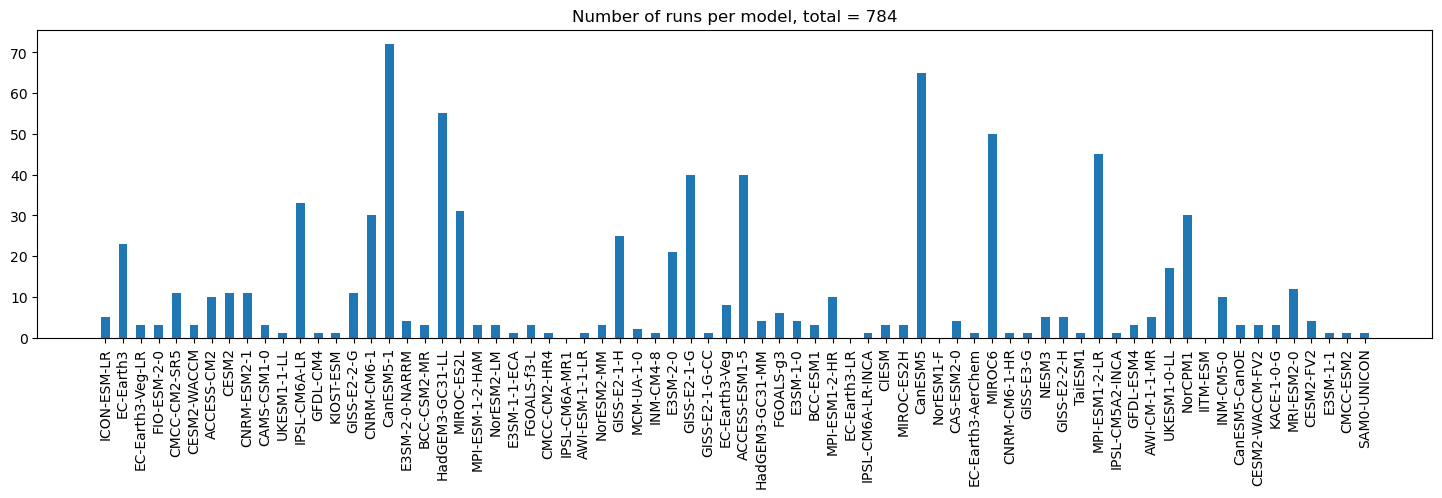

In [5]:
plot_histogram_runs(cope_data)

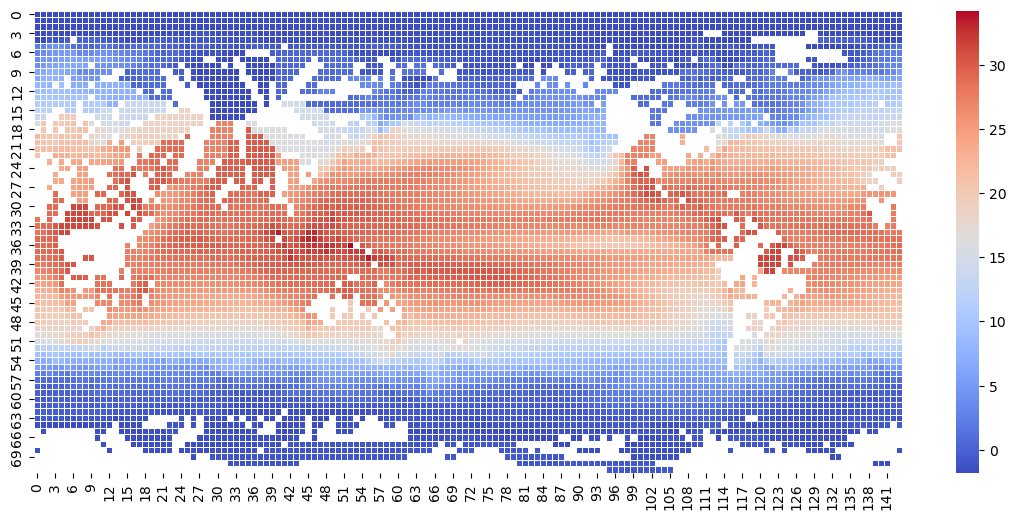

In [6]:
plot_heatmap(cope_data, model='ICON-ESM-LR', run='r1i1p1f1', year=1980)

## Preprocessing
The data is a bit messy, so we need to preprocess it. 
We first take out the models with less than five runs, we keep the latitudes under 60° degree and we also downscale the data to have less cells.


In [7]:
prune(cope_data, min_runs=5) # Remove runs with less than 5 years of data

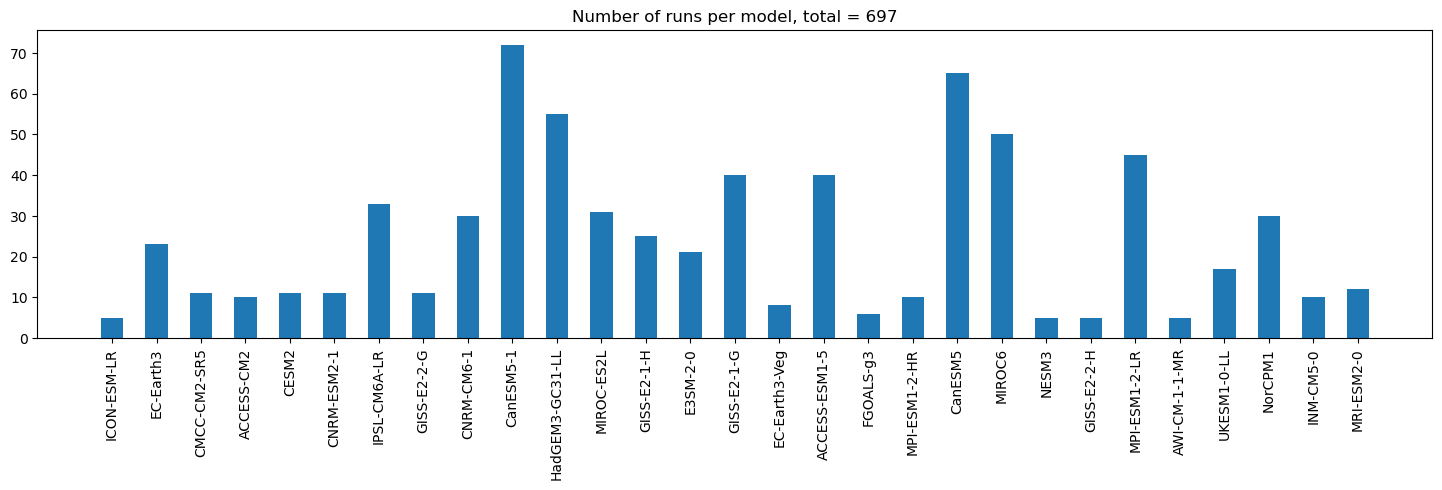

In [8]:
plot_histogram_runs(cope_data)

In [9]:
cut_lat(cope_data, max_lat=60) # Cut latitude to a maximum of 60 degrees
downscale(cope_data) # Downscale the data to a lower resolution

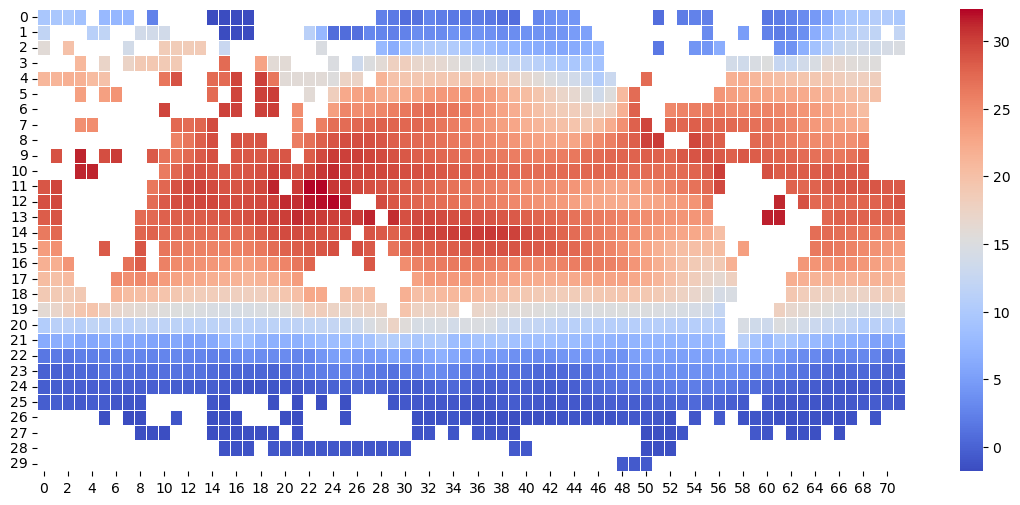

In [10]:
plot_heatmap(cope_data, model='ICON-ESM-LR', run='r1i1p1f1', year=1980)

We find the biggest possible mask of nans and we use it to set every grid to the same mask. 

In [11]:
union_nan_mask = find_union_nan_mask(cope_data) # Find the union of NaN masks across all variables
inpute(cope_data, union_nan_mask) # Inpute missing values using the union NaN mask

We also restrict the timesteps, using only data from 1980 to 2013.

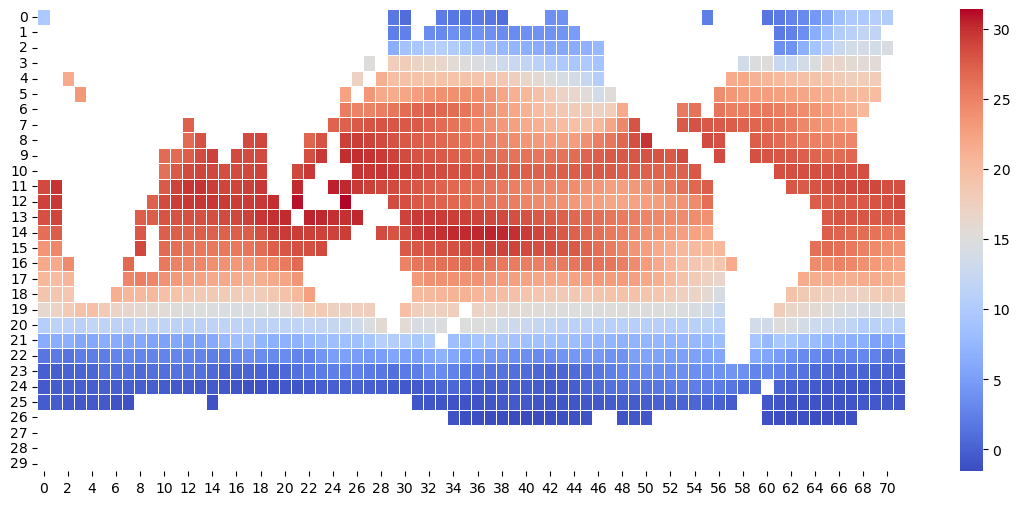

In [12]:
plot_heatmap(cope_data, model='ICON-ESM-LR', run='r1i1p1f1', year=1980)

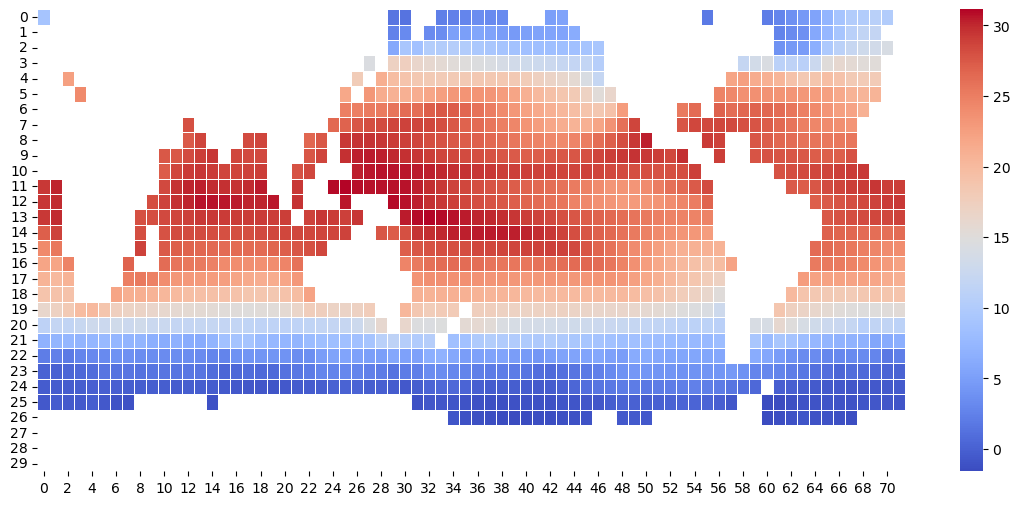

In [13]:
plot_heatmap(cope_data, model='ICON-ESM-LR', run='r1i1p1f1', year=2013)

## Normalization

We now plot the runs of the CanESM5-1 model in the cell (20, 50)

The formula to compute the mean of the runs is the following, where $i$ is the run, $p$ is the pixel, $m$ is the model and $t$ is the timestep

$$x^p_{i, t, m} = \frac{1}{T}\sum_{t}{\frac{1}{I}\sum_{i}{x^p_{i, t, m}}}$$

Notice that we compute the mean across the runs but across the time too. If we fix the pixel and the model, we get a single value.

To get the standard deviation we compute the std across the runs and then take the mean. We then have that the normalized timeserie is

$$\text{normalized timeserie} = (\text{timeserie} - \text{mean}) / \text{std}$$

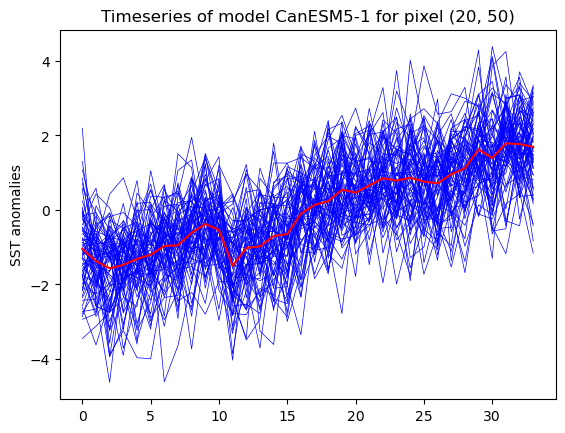

In [14]:
plot_timeseries(cope_data, model='CanESM5-1', pixel=(20, 50))

Another normalising option would be to compute the mean just across the runs, having a normalized timeserie that resembles this : 

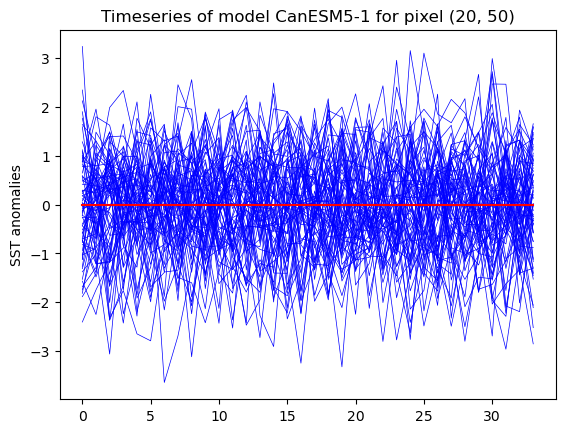

In [15]:
plot_timeseries_other(cope_data, model='CanESM5-1', pixel=(20, 50))

Throughout the rest of this project, we normalize the timeseries according to the first strategy.

## 1. Reduced Rank Regression